# Unit 2 — Linear models for regression

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Practice 1 — Implement linear regression to perform prediction

Predict tomorrow's highest temperature from today's weather. Least squares has a closed-form answer, the normal equation w = (XᵀX)⁻¹Xᵀy. Train on 2012–2014, test on 2015.

error on 2015:  'tomorrow = today' 2.91 °C  |  linear regression 2.68 °C   (R² = 0.87)

  weight of intercept     +4.93
  weight of precipitation -0.04
  weight of temp_max      +0.66
  weight of temp_min      +0.11
  weight of wind          -0.06
  weight of month_sin     -1.17
  weight of month_cos     -1.98


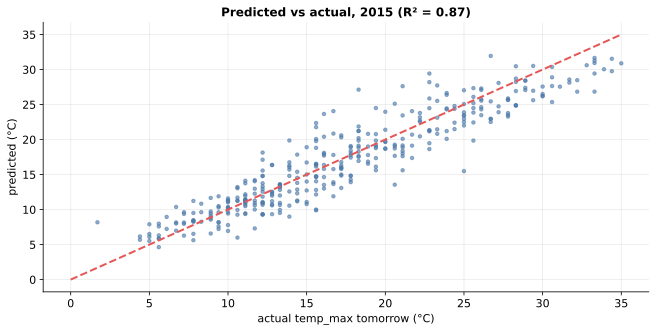

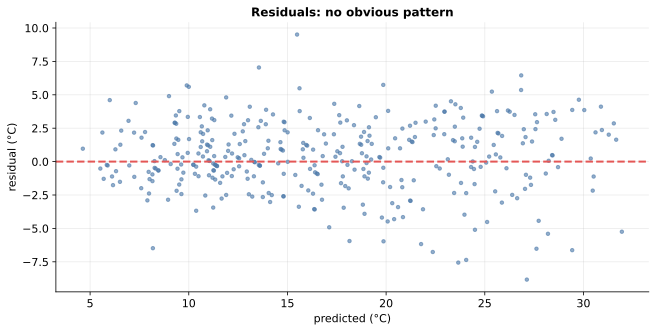

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load, split, FEATURES

train, test = split(load())                                       # train on 2012-2014, test on 2015
X_tr = np.c_[np.ones(len(train)), train[FEATURES]]                 # a column of ones is the intercept
X_te = np.c_[np.ones(len(test)), test[FEATURES]]
y_tr, y_te = train.temp_tomorrow.values, test.temp_tomorrow.values

w = np.linalg.solve(X_tr.T @ X_tr, X_tr.T @ y_tr)                  # the normal equation
pred = X_te @ w
rmse = lambda y, p: np.sqrt(np.mean((y - p) ** 2))
r2 = 1 - ((y_te - pred) ** 2).sum() / ((y_te - y_te.mean()) ** 2).sum()

print(f"error on 2015:  'tomorrow = today' {rmse(y_te, test.temp_max):.2f} °C  |  linear regression {rmse(y_te, pred):.2f} °C   (R² = {r2:.2f})\n")
for name, wi in zip(["intercept"] + FEATURES, w):
    print(f"  weight of {name:<13} {wi:+.2f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(y_te, pred, s=12, alpha=.6); ax.plot([0, 35], [0, 35], "--", color="#e45756")
ax.set_xlabel("actual temp_max tomorrow (°C)"); ax.set_ylabel("predicted (°C)"); ax.set_title(f"Predicted vs actual, 2015 (R² = {r2:.2f})")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(pred, y_te - pred, s=12, alpha=.6); ax.axhline(0, ls="--", color="#e45756")
ax.set_xlabel("predicted (°C)"); ax.set_ylabel("residual (°C)"); ax.set_title("Residuals: no obvious pattern")
plt.show()

## Practice 2 — Implement Bayesian logistic regression and SVM for classification

Will it rain tomorrow? Bayesian logistic regression uses the Laplace approximation: Newton's method finds the most probable weights and the curvature there gives their uncertainty. The SVM finds the widest margin between the classes; the RBF kernel lets the boundary curve.

'tomorrow = today' accuracy on 2015:   0.703
Bayesian logistic regression accuracy: 0.731
SVM (linear kernel) accuracy:          0.725   support vectors: 698
SVM (rbf kernel) accuracy:             0.720   support vectors: 699


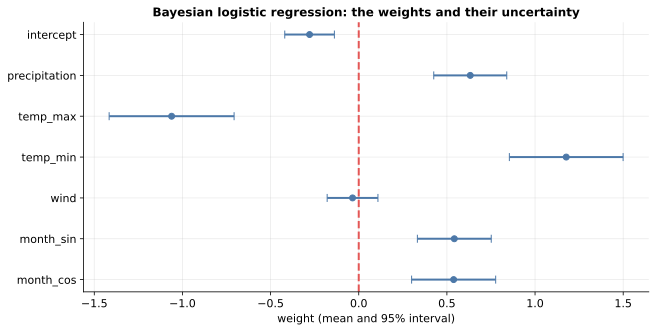

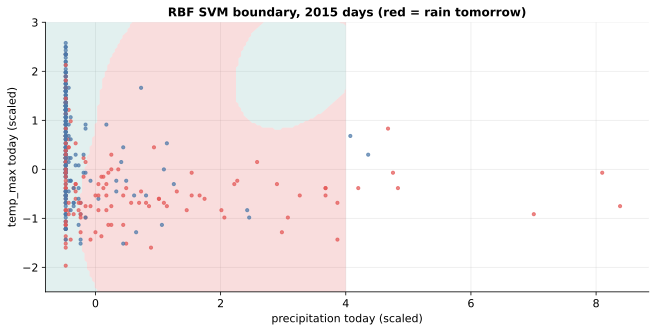

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from weather import load, split, FEATURES

train, test = split(load())
sc = StandardScaler().fit(train[FEATURES])
X, Xt = sc.transform(train[FEATURES]), sc.transform(test[FEATURES])
y, yt = train.rain_tomorrow.values, test.rain_tomorrow.values
sigmoid = lambda z: 1 / (1 + np.exp(-z))
print(f"{"'tomorrow = today' accuracy on 2015:":<38} {np.mean(test.rain.values == yt):.3f}")

# 1) Bayesian logistic regression (Laplace approximation, prior w ~ N(0, I))
A, At = np.c_[np.ones(len(X)), X], np.c_[np.ones(len(Xt)), Xt]
w = np.zeros(A.shape[1])
for _ in range(25):                                                  # Newton's method for the most probable weights
    p = sigmoid(A @ w)
    grad = A.T @ (p - y) + w
    hess = A.T @ (A * (p * (1 - p))[:, None]) + np.eye(len(w))
    w -= np.linalg.solve(hess, grad)
cov = np.linalg.inv(hess)                                            # posterior ≈ Gaussian(mean w, covariance cov)
mu, var = At @ w, np.einsum("ij,jk,ik->i", At, cov, At)
p_bayes = sigmoid(mu / np.sqrt(1 + np.pi * var / 8))                 # predictive probability, softened when unsure
print(f"{'Bayesian logistic regression accuracy:':<38} {np.mean((p_bayes > .5) == yt):.3f}")

# 2) Support vector machines
for kernel in ["linear", "rbf"]:
    svm = SVC(kernel=kernel, C=1.0).fit(X, y)
    print(f"{'SVM (' + kernel + ' kernel) accuracy:':<38} {svm.score(Xt, yt):.3f}   support vectors: {svm.n_support_.sum()}")

# Picture 1: what the data say about each weight (mean and 95% interval)
fig, ax = plt.subplots(figsize=(9, 4.5))
sd = np.sqrt(np.diag(cov))
ax.errorbar(w, range(len(w)), xerr=1.96 * sd, fmt="o", capsize=4)
ax.set_yticks(range(len(w)), ["intercept"] + FEATURES); ax.axvline(0, color="#e45756", ls="--"); ax.invert_yaxis()
ax.set_xlabel("weight (mean and 95% interval)"); ax.set_title("Bayesian logistic regression: the weights and their uncertainty")
plt.show()

# Picture 2: an RBF SVM on two features, so its curved boundary can be drawn

two = [FEATURES.index("precipitation"), FEATURES.index("temp_max")]
svm2 = SVC(kernel="rbf", C=1.0).fit(X[:, two], y)
xx, yy = np.meshgrid(np.linspace(-0.8, 4, 120), np.linspace(-2.5, 3, 120))
zz = svm2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.contourf(xx, yy, zz, levels=[-.5, .5, 1.5], colors=["#72b7b2", "#e45756"], alpha=.2)
ax.scatter(Xt[:, two[0]], Xt[:, two[1]], c=np.where(yt == 1, "#e45756", "#4c78a8"), s=10, alpha=.7)
ax.set_xlabel("precipitation today (scaled)"); ax.set_ylabel("temp_max today (scaled)")
ax.set_title("RBF SVM boundary, 2015 days (red = rain tomorrow)")
plt.show()